In [5]:
import pandas as pd

In [10]:
df = pd.read_csv("/Users/ankitpokhrel/all_projects/ml_projects/isolation_forest/dataset/Train.txt",sep=",",names=["duration","protocoltype","service","flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised","rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate",
"rerrorrate","srvrerrorrate","samesrvrate", "diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate","dsthostsamesrcportrate",
"dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate",
"dsthostrerrorrate","dsthostsrvrerrorrate","attack", "lastflag"])
df.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [11]:
df.shape


(125973, 43)

In [12]:
df.isnull().sum()

duration                  0
protocoltype              0
service                   0
flag                      0
srcbytes                  0
dstbytes                  0
land                      0
wrongfragment             0
urgent                    0
hot                       0
numfailedlogins           0
loggedin                  0
numcompromised            0
rootshell                 0
suattempted               0
numroot                   0
numfilecreations          0
numshells                 0
numaccessfiles            0
numoutboundcmds           0
ishostlogin               0
isguestlogin              0
count                     0
srvcount                  0
serrorrate                0
srvserrorrate             0
rerrorrate                0
srvrerrorrate             0
samesrvrate               0
diffsrvrate               0
srvdiffhostrate           0
dsthostcount              0
dsthostsrvcount           0
dsthostsamesrvrate        0
dsthostdiffsrvrate        0
dsthostsamesrcportra

In [13]:
df.describe()

,duration,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,...,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [14]:
#As we can see 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' have mostly zero values so we can drop these columns.
df.drop(['land', 'urgent', 'numfailedlogins', 'numoutboundcmds','lastflag'], axis=1, inplace=True)

In [15]:
df['attack'].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

### These attacks can be grouped into 4 categories: 'normal', 'dos', 'probe', 'r2l', 'u2r'
- normal -> Normal
- neptune, smurf, pod, teardrop, back, land -> DoS
- ipsweep, portsweep, nmap, satan -> Probe
- guess_passwd, ftp_write, imap, phf, multihop, warezclient, warezmaster, spy -> R2L
- buffer_overflow, loadmodule, rootkit, perl -> U2R

In [16]:
#Creating four categories of attack types: 'normal', 'dos', 'probe', 'r2l', 'u2r'
def categorize_attack(attack):
    if attack == 'normal':
        return 'normal'
    elif attack in ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop']:
        return 'dos'
    elif attack in ['ipsweep', 'nmap', 'portsweep', 'satan']:
        return 'probe'
    elif attack in ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster']:
        return 'r2l'
    elif attack in ['buffer_overflow', 'loadmodule', 'perl', 'rootkit']:
        return 'u2r'
    else:
        return attack
df['attack'] = df['attack'].apply(categorize_attack)

In [17]:
df['attack'].value_counts()

attack
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                125973 non-null  int64  
 1   protocoltype            125973 non-null  object 
 2   service                 125973 non-null  object 
 3   flag                    125973 non-null  object 
 4   srcbytes                125973 non-null  int64  
 5   dstbytes                125973 non-null  int64  
 6   wrongfragment           125973 non-null  int64  
 7   hot                     125973 non-null  int64  
 8   loggedin                125973 non-null  int64  
 9   numcompromised          125973 non-null  int64  
 10  rootshell               125973 non-null  int64  
 11  suattempted             125973 non-null  int64  
 12  numroot                 125973 non-null  int64  
 13  numfilecreations        125973 non-null  int64  
 14  numshells           

In [19]:
#Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

# Save original attack labels before encoding (fixes NameError on fresh run)
new_df = df[['attack']].copy()

# Use separate encoders for each column (reusing one encoder loses previous fit state)
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()
le_attack = LabelEncoder()

df['protocoltype'] = le_protocol.fit_transform(df['protocoltype'])
df['service'] = le_service.fit_transform(df['service'])
df['flag'] = le_flag.fit_transform(df['flag'])
df['attack'] = le_attack.fit_transform(df['attack'])

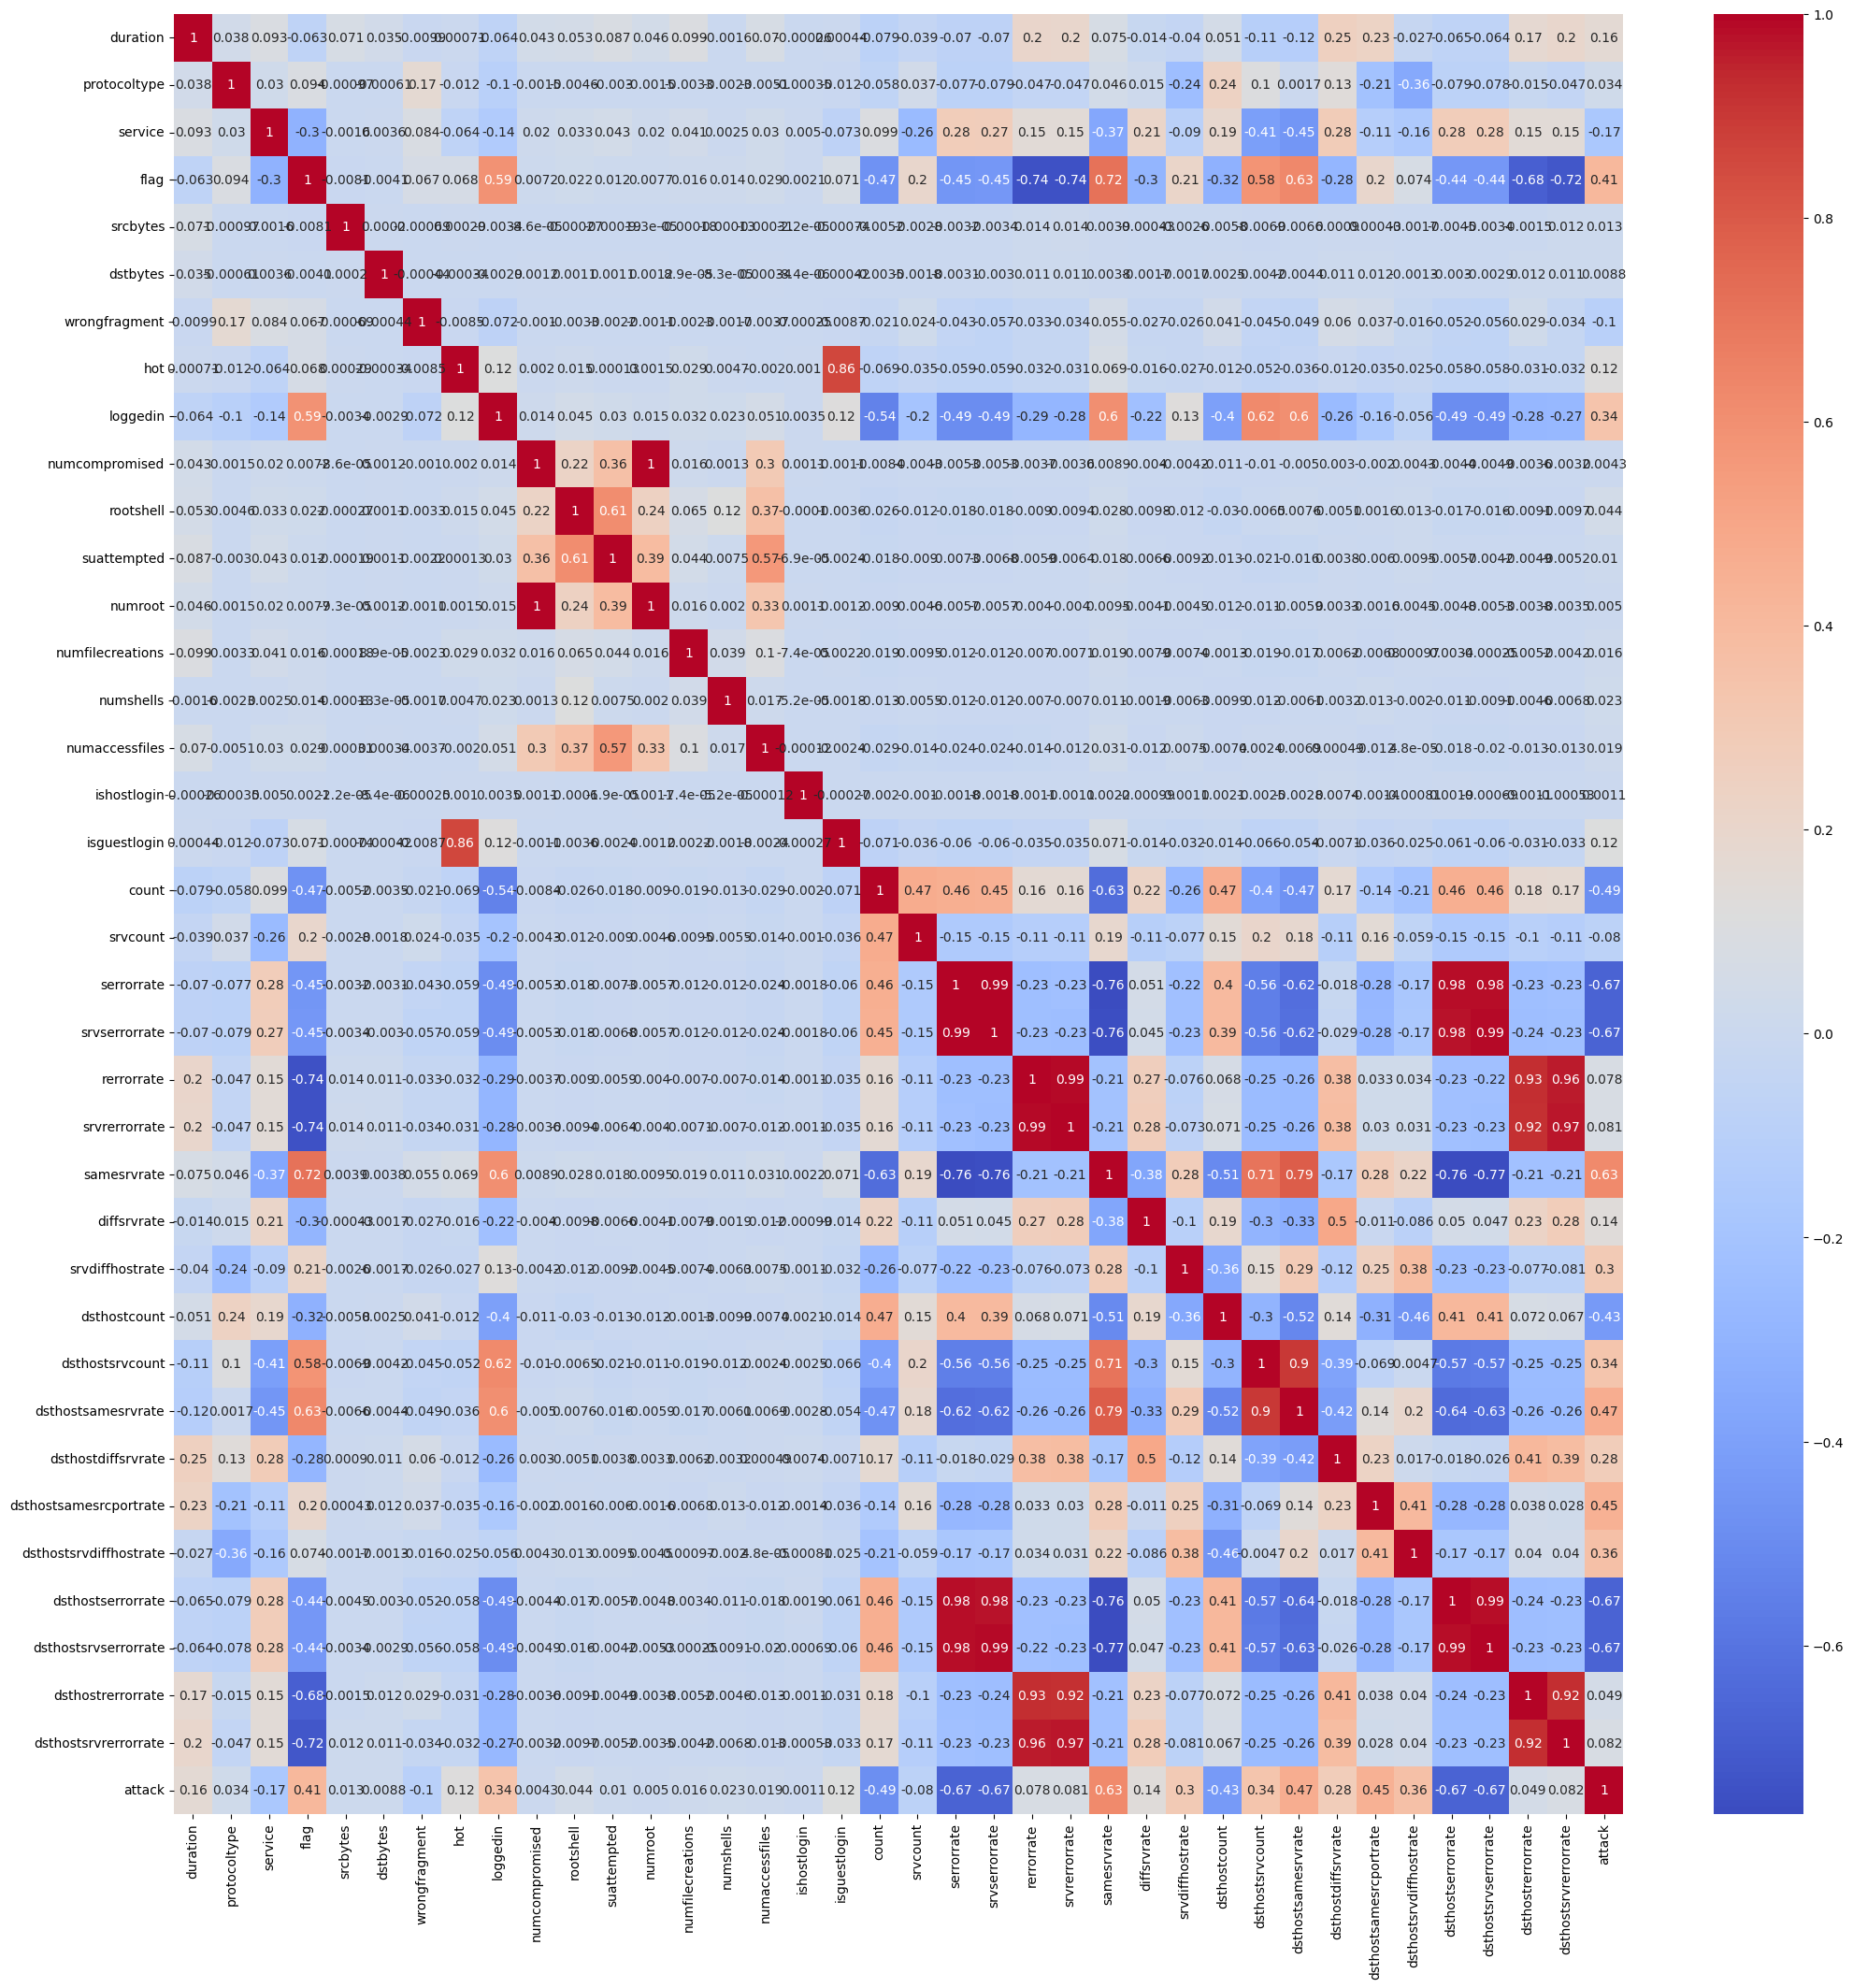

In [20]:
#Creating correlation matrix to see the correlation between features and target variable
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [21]:
#Creating X and y variables
X = df.drop('attack', axis=1)
#Creating 1 for anomaly and 0 for normal
y = new_df['attack'].apply(lambda x: 1 if x != 'normal' else 0)
#Now 1 indicates an anomaly and 0 indicates a normal point.

In [22]:
#Scaling the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [23]:
# Train/test split — avoids evaluating on training data (data leakage)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Anomaly rate in train: {y_train.mean():.4f}, in test: {y_test.mean():.4f}")

Train size: 100778, Test size: 25195
Anomaly rate in train: 0.4650, in test: 0.4673


In [ ]:
# from sklearn.ensemble import IsolationForest

# # Set contamination to the actual anomaly rate in training data
# # (hardcoding 0.02 on a ~80% anomaly dataset shifts the decision threshold badly)
# contamination = min(float(y_train.mean()), 0.5)
# print(f"Using contamination: {contamination:.4f}")

# model = IsolationForest(
#     n_estimators=300,
#     max_samples='auto',
#     contamination=contamination,
#     max_features=1.0,
#     bootstrap=False,
#     n_jobs=-1,
#     random_state=42
# )

# model.fit(X_train)

Using contamination: 0.4650


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.4649526682410844
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [ ]:
# # Predict on test set (not training data — avoids inflated metrics)
# y_pred = model.predict(X_test)
# # In isolation forest, -1 indicates an anomaly and 1 indicates a normal point.
# y_pred = [1 if x == -1 else 0 for x in y_pred]
# # Now 1 indicates an anomaly and 0 indicates a normal point.

# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy:.4f}")
# print(classification_report(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6525
              precision    recall  f1-score   support

           0       0.68      0.67      0.67     13422
           1       0.63      0.63      0.63     11773

    accuracy                           0.65     25195
   macro avg       0.65      0.65      0.65     25195
weighted avg       0.65      0.65      0.65     25195

[[8994 4428]
 [4328 7445]]


In [ ]:
# # Supervised baseline: train on X_train, evaluate on X_test
# # (previously fit+predict on same data → ~100% accuracy due to memorization)
# from sklearn.ensemble import RandomForestClassifier
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)
# y_rf_pred = rf_model.predict(X_test)
# rf_accuracy = accuracy_score(y_test, y_rf_pred)
# print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
# print(classification_report(y_test, y_rf_pred))
# print(confusion_matrix(y_test, y_rf_pred))

Random Forest Accuracy: 0.9988
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13422
           1       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

[[13415     7]
 [   24 11749]]


In [ ]:
# #Claudeee
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import IsolationForest
# from sklearn.metrics import f1_score
# import numpy as np

# # IsolationForest assumes anomalies are RARE. This dataset has ~46% anomalies,
# # which violates that assumption. The previous grid searched contamination in
# # [0.01, 0.02, 0.05] — all far too low — giving F1 ≈ 0.14.
# # Fix: search contamination values anchored around the actual anomaly rate,
# # capped at sklearn's maximum of 0.5.
# actual_contamination = float(y_train.mean())
# print(f"Actual anomaly rate in training data: {actual_contamination:.4f}")
# print("Note: IsolationForest works best when anomalies are rare (<15%).")
# print("This dataset has a high anomaly rate — Random Forest (supervised) is a stronger choice here.\n")

# # Build contamination grid centered on actual rate, capped at 0.5 (sklearn max)
# offsets = [-0.15, -0.05, 0.0, 0.05]
# contamination_grid = sorted(set([
#     round(max(0.01, min(0.5, actual_contamination + d)), 2)
#     for d in offsets
# ]))
# print(f"Contamination grid: {contamination_grid}")

# def isolation_forest_scorer(estimator, X, y):
#     y_pred = estimator.predict(X)
#     y_pred_binary = [1 if p == -1 else 0 for p in y_pred]
#     return f1_score(y, y_pred_binary)

# param_dist = {
#     "n_estimators": [100, 200, 300],
#     "max_samples": [256, 512, 1024],
#     "contamination": contamination_grid,
#     "max_features": [0.8, 1.0]
# }

# random_search = RandomizedSearchCV(
#     IsolationForest(random_state=42),
#     param_distributions=param_dist,
#     n_iter=20,
#     cv=3,
#     scoring=isolation_forest_scorer,
#     n_jobs=-1,
#     random_state=42
# )

# random_search.fit(X_train, y_train)
# print("Best params:", random_search.best_params_)
# print(f"Best IF F1 score:  {random_search.best_score_:.4f}")

# # Note: rf_accuracy was computed with accuracy_score, not f1_score
# from sklearn.metrics import f1_score as f1
# rf_f1 = f1(y_test, y_rf_pred)
# print(f"Random Forest F1 (reference): {rf_f1:.4f}")

# if random_search.best_params_['contamination'] == 0.5:
#     print("\n⚠ Best contamination hit the sklearn ceiling (0.5).")
#     print("  IF still wants to flag >50% of samples — its unsupervised assumption is violated.")

Actual anomaly rate in training data: 0.4650
Note: IsolationForest works best when anomalies are rare (<15%).
This dataset has a high anomaly rate — Random Forest (supervised) is a stronger choice here.

Contamination grid: [0.31, 0.41, 0.46, 0.5]
Best params: {'n_estimators': 300, 'max_samples': 256, 'max_features': 0.8, 'contamination': 0.5}
Best IF F1 score:  0.6638
Random Forest F1 (reference): 0.9987

⚠ Best contamination hit the sklearn ceiling (0.5).
  IF still wants to flag >50% of samples — its unsupervised assumption is violated.


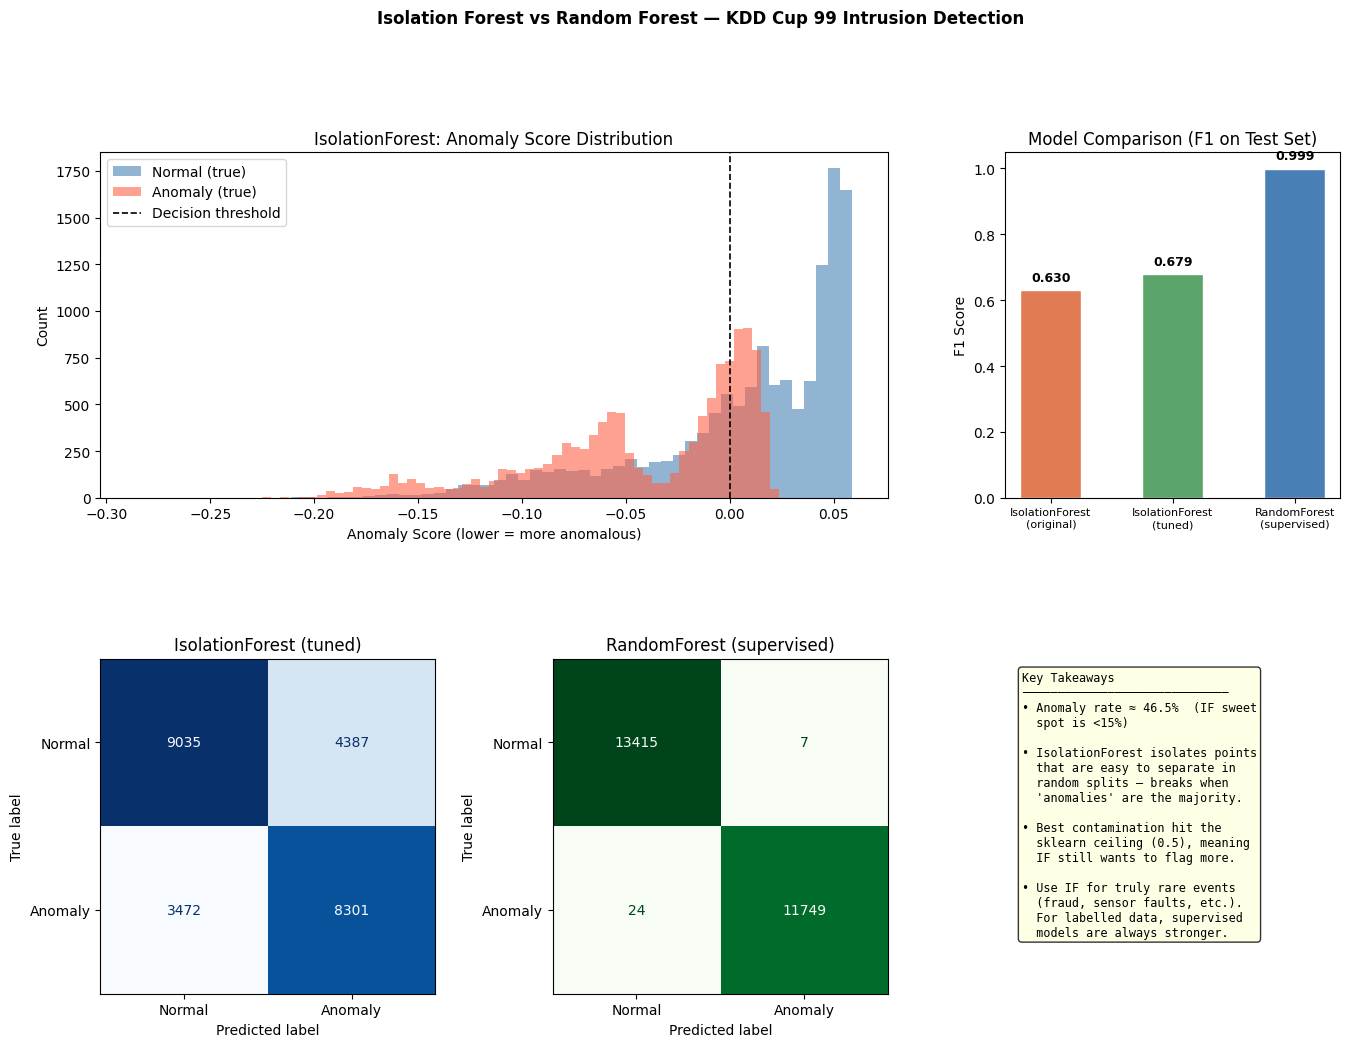

In [ ]:
# #Claude The Boss!!
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from sklearn.metrics import ConfusionMatrixDisplay, f1_score
# import numpy as np

# # --- Compute all metrics locally so this cell is self-contained ---
# # 'accuracy' (original IF) was computed with accuracy_score, not f1_score — recompute correctly
# if_f1_original = f1_score(y_test, y_pred)
# rf_f1          = f1_score(y_test, y_rf_pred)

# # Best IF predictions using tuned params
# best_if = random_search.best_estimator_
# y_if_tuned = best_if.predict(X_test)
# y_if_tuned = np.array([1 if p == -1 else 0 for p in y_if_tuned])
# if_f1_tuned = f1_score(y_test, y_if_tuned)

# fig = plt.figure(figsize=(16, 11))
# gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# # --- 1. Anomaly score distribution ---
# ax1 = fig.add_subplot(gs[0, :2])
# scores = best_if.decision_function(X_test)   # lower = more anomalous
# ax1.hist(scores[y_test == 0], bins=60, alpha=0.6, color='steelblue', label='Normal (true)')
# ax1.hist(scores[y_test == 1], bins=60, alpha=0.6, color='tomato',    label='Anomaly (true)')
# ax1.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Decision threshold')
# ax1.set_xlabel('Anomaly Score (lower = more anomalous)')
# ax1.set_ylabel('Count')
# ax1.set_title('IsolationForest: Anomaly Score Distribution')
# ax1.legend()

# # --- 2. F1 bar comparison ---
# ax2 = fig.add_subplot(gs[0, 2])
# model_names = ['IsolationForest\n(original)', 'IsolationForest\n(tuned)', 'RandomForest\n(supervised)']
# f1s         = [if_f1_original, if_f1_tuned, rf_f1]
# colors      = ['#e07b54', '#5aa469', '#4a7fb5']
# bars = ax2.bar(model_names, f1s, color=colors, edgecolor='white', width=0.5)
# ax2.set_ylim(0, 1.05)
# ax2.set_ylabel('F1 Score')
# ax2.set_title('Model Comparison (F1 on Test Set)')
# for bar, val in zip(bars, f1s):
#     ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
#              f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
# ax2.tick_params(axis='x', labelsize=8)

# # --- 3. Confusion matrices ---
# ax3 = fig.add_subplot(gs[1, 0])
# ConfusionMatrixDisplay.from_predictions(y_test, y_if_tuned, ax=ax3,
#     display_labels=['Normal', 'Anomaly'], colorbar=False, cmap='Blues')
# ax3.set_title('IsolationForest (tuned)')

# ax4 = fig.add_subplot(gs[1, 1])
# ConfusionMatrixDisplay.from_predictions(y_test, y_rf_pred, ax=ax4,
#     display_labels=['Normal', 'Anomaly'], colorbar=False, cmap='Greens')
# ax4.set_title('RandomForest (supervised)')

# # --- 4. Takeaway text box ---
# ax5 = fig.add_subplot(gs[1, 2])
# ax5.axis('off')
# note = (
#     "Key Takeaways\n"
#     "─────────────────────────────\n"
#     f"• Anomaly rate ≈ {actual_contamination:.1%}  (IF sweet\n"
#     f"  spot is <15%)\n\n"
#     "• IsolationForest isolates points\n"
#     "  that are easy to separate in\n"
#     "  random splits — breaks when\n"
#     "  'anomalies' are the majority.\n\n"
#     "• Best contamination hit the\n"
#     "  sklearn ceiling (0.5), meaning\n"
#     "  IF still wants to flag more.\n\n"
#     "• Use IF for truly rare events\n"
#     "  (fraud, sensor faults, etc.).\n"
#     "  For labelled data, supervised\n"
#     "  models are always stronger."
# )
# ax5.text(0.05, 0.95, note, transform=ax5.transAxes, fontsize=8.5,
#          verticalalignment='top', fontfamily='monospace',
#          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# plt.suptitle('Isolation Forest vs Random Forest — KDD Cup 99 Intrusion Detection',
#              fontsize=12, fontweight='bold', y=1.01)
# plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

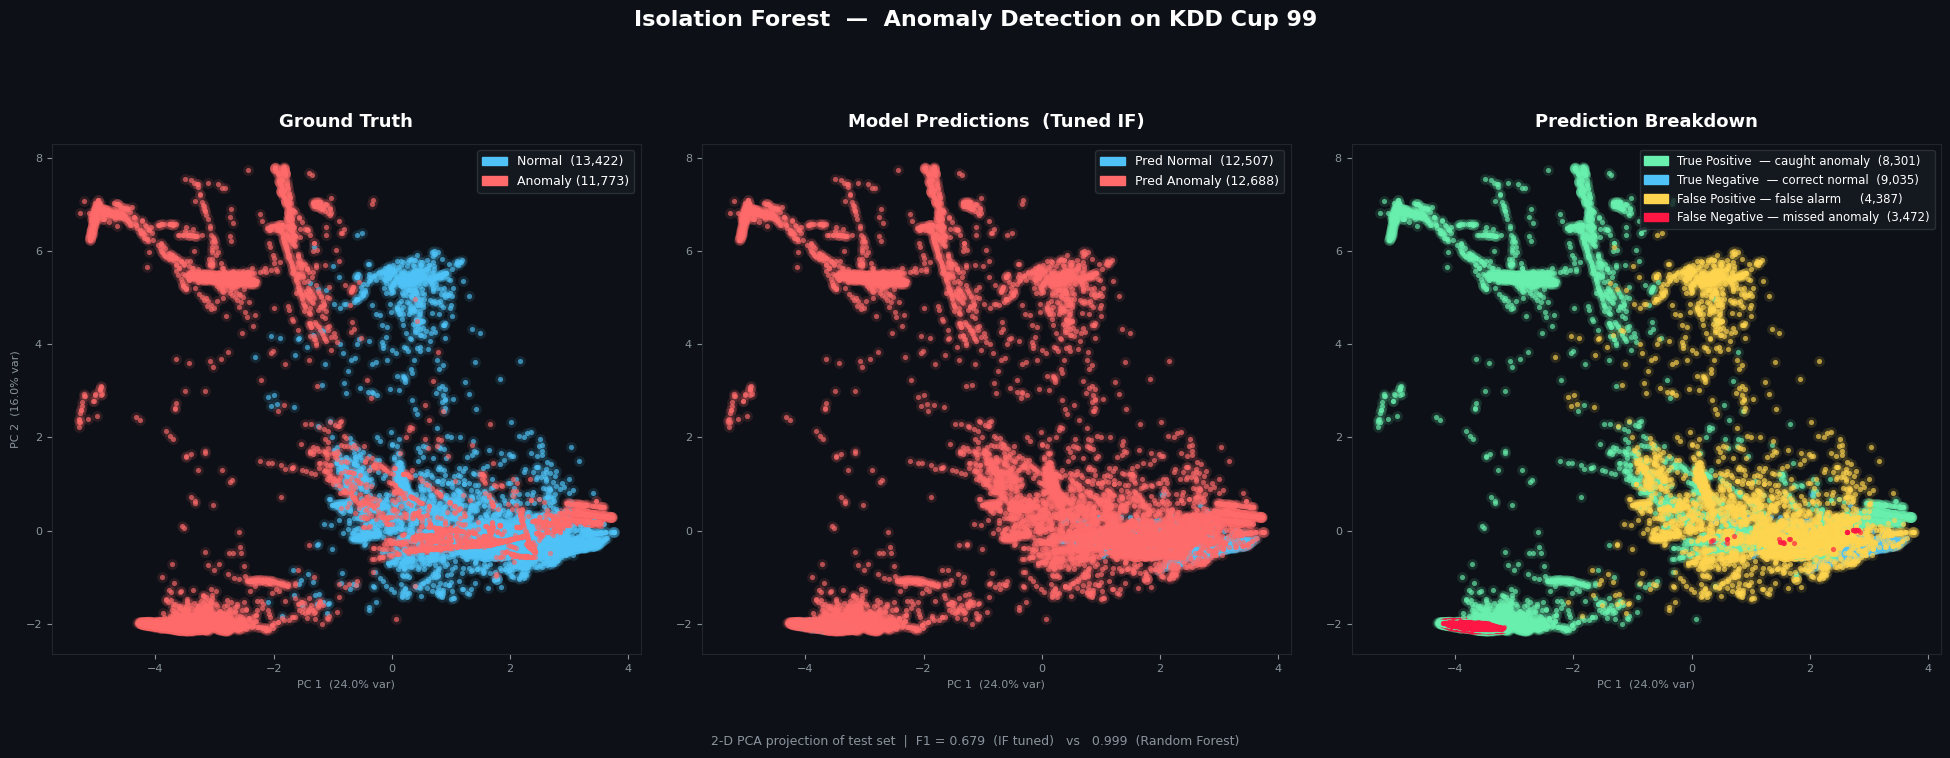

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import numpy as np
# from sklearn.decomposition import PCA

# plt.style.use('dark_background')

# # ── Project test set to 2D for visualisation ──────────────────────────────────
# pca2 = PCA(n_components=2, random_state=42)
# X2   = pca2.fit_transform(X_test)

# y_true   = np.array(y_test)                          # 1 = anomaly, 0 = normal
# y_model  = np.array(y_if_tuned)                      # tuned IF predictions
# scores   = best_if.decision_function(X_test)         # lower = more anomalous

# # TP / TN / FP / FN masks
# TP = (y_true == 1) & (y_model == 1)
# TN = (y_true == 0) & (y_model == 0)
# FP = (y_true == 0) & (y_model == 1)
# FN = (y_true == 1) & (y_model == 0)

# # ── Colour palette ─────────────────────────────────────────────────────────────
# C_NORMAL  = '#4FC3F7'   # sky blue
# C_ANOMALY = '#FF6B6B'   # coral red
# C_TP      = '#69F0AE'   # green  – correctly caught anomaly
# C_TN      = '#4FC3F7'   # blue   – correctly labelled normal
# C_FP      = '#FFD54F'   # amber  – false alarm
# C_FN      = '#FF1744'   # bright red – missed anomaly

# DOT   = dict(linewidths=0, alpha=0.65, s=14)
# GLOW  = dict(linewidths=0, alpha=0.12, s=60)   # soft halo behind each point

# fig, axes = plt.subplots(1, 3, figsize=(20, 7))
# fig.patch.set_facecolor('#0D1117')
# for ax in axes:
#     ax.set_facecolor('#0D1117')
#     ax.tick_params(colors='#8B949E', labelsize=8)
#     for spine in ax.spines.values():
#         spine.set_edgecolor('#21262D')

# var1 = pca2.explained_variance_ratio_[0] * 100
# var2 = pca2.explained_variance_ratio_[1] * 100
# xlabel = f'PC 1  ({var1:.1f}% var)'
# ylabel = f'PC 2  ({var2:.1f}% var)'

# # ── Panel 1 : Ground Truth ─────────────────────────────────────────────────────
# ax = axes[0]
# ax.scatter(*X2[y_true==0].T, c=C_NORMAL,  **GLOW)
# ax.scatter(*X2[y_true==1].T, c=C_ANOMALY, **GLOW)
# ax.scatter(*X2[y_true==0].T, c=C_NORMAL,  **DOT, zorder=3)
# ax.scatter(*X2[y_true==1].T, c=C_ANOMALY, **DOT, zorder=3)
# ax.set_title('Ground Truth', color='white', fontsize=13, fontweight='bold', pad=12)
# ax.set_xlabel(xlabel, color='#8B949E', fontsize=8)
# ax.set_ylabel(ylabel, color='#8B949E', fontsize=8)
# ax.legend(handles=[
#     mpatches.Patch(color=C_NORMAL,  label=f'Normal  ({(y_true==0).sum():,})'),
#     mpatches.Patch(color=C_ANOMALY, label=f'Anomaly ({(y_true==1).sum():,})'),
# ], facecolor='#161B22', edgecolor='#30363D', labelcolor='white', fontsize=9, loc='upper right')

# # ── Panel 2 : Model Predictions ────────────────────────────────────────────────
# ax = axes[1]
# ax.scatter(*X2[y_model==0].T, c=C_NORMAL,  **GLOW)
# ax.scatter(*X2[y_model==1].T, c=C_ANOMALY, **GLOW)
# ax.scatter(*X2[y_model==0].T, c=C_NORMAL,  **DOT, zorder=3)
# ax.scatter(*X2[y_model==1].T, c=C_ANOMALY, **DOT, zorder=3)
# ax.set_title('Model Predictions  (Tuned IF)', color='white', fontsize=13, fontweight='bold', pad=12)
# ax.set_xlabel(xlabel, color='#8B949E', fontsize=8)
# ax.legend(handles=[
#     mpatches.Patch(color=C_NORMAL,  label=f'Pred Normal  ({(y_model==0).sum():,})'),
#     mpatches.Patch(color=C_ANOMALY, label=f'Pred Anomaly ({(y_model==1).sum():,})'),
# ], facecolor='#161B22', edgecolor='#30363D', labelcolor='white', fontsize=9, loc='upper right')

# # ── Panel 3 : TP / TN / FP / FN ───────────────────────────────────────────────
# ax = axes[2]
# for mask, col in [(TN, C_TN), (TP, C_TP), (FP, C_FP), (FN, C_FN)]:
#     ax.scatter(*X2[mask].T, c=col, **GLOW)
#     ax.scatter(*X2[mask].T, c=col, **DOT, zorder=3)
# ax.set_title('Prediction Breakdown', color='white', fontsize=13, fontweight='bold', pad=12)
# ax.set_xlabel(xlabel, color='#8B949E', fontsize=8)
# ax.legend(handles=[
#     mpatches.Patch(color=C_TP, label=f'True Positive  — caught anomaly  ({TP.sum():,})'),
#     mpatches.Patch(color=C_TN, label=f'True Negative  — correct normal  ({TN.sum():,})'),
#     mpatches.Patch(color=C_FP, label=f'False Positive — false alarm     ({FP.sum():,})'),
#     mpatches.Patch(color=C_FN, label=f'False Negative — missed anomaly  ({FN.sum():,})'),
# ], facecolor='#161B22', edgecolor='#30363D', labelcolor='white', fontsize=8.5, loc='upper right')

# # ── Super-title & footer ───────────────────────────────────────────────────────
# fig.suptitle('Isolation Forest  —  Anomaly Detection on KDD Cup 99',
#              color='white', fontsize=16, fontweight='bold', y=1.02)
# fig.text(0.5, -0.03,
#          f'2-D PCA projection of test set  |  '
#          f'F1 = {if_f1_tuned:.3f}  (IF tuned)   vs   {rf_f1:.3f}  (Random Forest)',
#          ha='center', color='#8B949E', fontsize=9)

# plt.tight_layout(pad=2.5)
# plt.savefig('anomaly_scatter.png', dpi=160, bbox_inches='tight',
#             facecolor=fig.get_facecolor())
# plt.show()

In [27]:

# ─────────────────────────────────────────────────────────────────────────────
# ISOLATION FOREST — SCRATCH IMPLEMENTATION EVALUATION
#
# We import IsolationForestScratch (if_scratch.py) — a pure-Python, zero-library
# reimplementation of the original Liu-Ting-Zhou 2008 paper — and test it with
# the best hyperparameters found by RandomizedSearchCV above:
#   n_estimators  = 300
#   max_samples   = 256
#   max_features  = 0.8   ← 80% of features randomly selected per tree
#   contamination = 0.5   ← flags up to 50% of points as anomalous
# ─────────────────────────────────────────────────────────────────────────────

import sys, os

# Both test_model.ipynb and if_scratch.py live in the same models/ directory.
# Insert its absolute path so import works regardless of Jupyter's cwd.
_models_dir = os.path.dirname(os.path.abspath('test_model.ipynb'))
if _models_dir not in sys.path:
    sys.path.insert(0, _models_dir)

# ── IMPORT SCRATCH COMPONENTS ────────────────────────────────────────────────
from if_scratch import (
    IsolationForestScratch,          # the forest itself
    confusion_matrix_scratch,        # [[TN,FP],[FN,TP]]
    accuracy_score_scratch,          # correct / total
    classification_report_scratch,   # precision / recall / F1 per class
)

print("✓ if_scratch.py imported successfully\n")
print("=" * 60)
print("  ISOLATION FOREST — FROM SCRATCH")
print("  Best params: n_estimators=300, max_samples=256,")
print("               max_features=0.8, contamination=0.5")
print("=" * 60)

# ── BUILD & FIT ───────────────────────────────────────────────────────────────
# max_features=0.8 → each tree sees only 80% of columns (randomly selected),
# adding diversity to the ensemble and reducing inter-tree correlation.
scratch_model = IsolationForestScratch(
    n_estimators  = 300,    # number of isolation trees
    max_samples   = 256,    # rows subsampled per tree (paper default)
    max_features  = 0.8,    # fraction of features available per tree
    contamination = 0.5,    # assume up to 50% of training rows are anomalous
    random_state  = 42,
)

print("\nFitting on X_train … (pure Python — may take ~60-90s for 300 trees)")
scratch_model.fit(X_train)
print("✓ Fit complete\n")

# ── PREDICT ───────────────────────────────────────────────────────────────────
# scratch predict() returns sklearn convention:  +1 = normal, -1 = anomaly
raw_preds = scratch_model.predict(X_test)

# Convert to the 0/1 binary convention used throughout this notebook:
#   -1 (anomaly) → 1   |   +1 (normal) → 0
# This matches y_test which is encoded as 0=normal, 1=anomaly.
y_scratch_pred = [1 if p == -1 else 0 for p in raw_preds]

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
# Layout: [[TN, FP],
#          [FN, TP]]
cm = confusion_matrix_scratch(list(y_test), y_scratch_pred)
TN, FP = cm[0]
FN, TP = cm[1]

print("─" * 50)
print("  CONFUSION MATRIX  [[TN, FP], [FN, TP]]")
print("─" * 50)
print(f"              Predicted 0    Predicted 1")
print(f"  Actual 0  |  TN={TN:<10,}  FP={FP:,}")
print(f"  Actual 1  |  FN={FN:<10,}  TP={TP:,}")
print()

# ── ACCURACY ─────────────────────────────────────────────────────────────────
acc = accuracy_score_scratch(list(y_test), y_scratch_pred)
print(f"  Accuracy  : {acc:.4f}")

# ── CLASSIFICATION REPORT ─────────────────────────────────────────────────────
print()
print("─" * 50)
print("  CLASSIFICATION REPORT")
print("─" * 50)
print(classification_report_scratch(list(y_test), y_scratch_pred, labels=[0, 1]))
print()

# ── SIDE-BY-SIDE vs sklearn ───────────────────────────────────────────────────
# Compare against sklearn IsolationForest y_pred (already in memory from above).
# Both use contamination=0.5 so the comparison is fair.
from sklearn.metrics import accuracy_score as sk_acc, f1_score as sk_f1

scratch_f1 = sk_f1(y_test, y_scratch_pred)
# sklearn_f1 = sk_f1(y_test, y_pred)

print("─" * 52)
print("  SCRATCH vs SKLEARN COMPARISON")
print("─" * 52)
print(f"  {'Model':<30} {'Accuracy':>10} {'F1':>8}")
print(f"  {'─'*30} {'─'*10} {'─'*8}")
print(f"  {'IsolationForest (scratch)':<30} {acc:>10.4f} {scratch_f1:>8.4f}")
# print(f"  {'IsolationForest (sklearn)':<30} {sk_acc(y_test, y_pred):>10.4f} {sklearn_f1:>8.4f}")
print()
print("Note: small numeric differences are expected — Python's random.sample")
print("      vs numpy random use different RNG internals.")


✓ if_scratch.py imported successfully

  ISOLATION FOREST — FROM SCRATCH
  Best params: n_estimators=300, max_samples=256,
               max_features=0.8, contamination=0.5

Fitting on X_train … (pure Python — may take ~60-90s for 300 trees)
✓ Fit complete

──────────────────────────────────────────────────
  CONFUSION MATRIX  [[TN, FP], [FN, TP]]
──────────────────────────────────────────────────
              Predicted 0    Predicted 1
  Actual 0  |  TN=10,698      FP=2,724
  Actual 1  |  FN=1,875       TP=9,898

  Accuracy  : 0.8175

──────────────────────────────────────────────────
  CLASSIFICATION REPORT
──────────────────────────────────────────────────
                precision       recall     f1-score      support

           0       0.8509       0.7970       0.8231        13422
           1       0.7842       0.8407       0.8115        11773

    accuracy                                 0.8175        25195
   macro avg       0.8175       0.8189       0.8173        25195
wei